# Ensembl VEP Annotations









In [8]:
%load_ext autoreload
%autoreload 2

import os
# only load this one time per session
if 'NOTEBOOK_INITIALIZED' not in globals():
    os.chdir(os.path.dirname(os.path.abspath('.')))
    NOTEBOOK_INITIALIZED = True


import src.utils as utils  
import src.ensemblVEP as ev
import src.onekg as og
import src.haplosaurus as hs

import matplotlib.pyplot as plt
import seaborn as sns
import pooch
from tqdm import tqdm
import polars as pl
import glob 
import pandas as pd
import numpy as np


utils.set_rcparams_nature()
pd.set_option('display.max_columns', None)


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Import VEP results

### ESM

In [218]:
# Focus on one model for the main plots
model_name = "esm2_t33_650M_UR50D"
model_name_display="ESM2-650M"      

force = False
tmp_vep_path = os.path.expanduser("~/projects/VEP_protein/results/data/vep_df_esm2_t33_650M_UR50D.parquet")
if os.path.exists(tmp_vep_path) and not force:
    print(f"Loading {tmp_vep_path}")
    vep_df = pd.read_parquet(tmp_vep_path)
# "Location" is already in the dataframe 
# Set cached annotation file path
cached_file = os.path.join(pooch.os_cache("pooch"), "cv_annot_ProteinGym_missense.parquet")
 
vep_df = utils.add_variant_name(vep_df,  
                                      chrom_col='#CHROM',
                                    start_col='POS',
                                    end_col=None,
                                    ref_col='REF',
                                    alt_col='ALT',
                                    alias='site', 
                                    force=True # <--- KEEP THIS TRUE!!! site naming changed since I saved the parquet file
                                    )
model_name_display="ESM2-650M"                                    
 
vep_df.head() 

Loading /home/schilder/projects/VEP_protein/results/data/vep_df_esm2_t33_650M_UR50D.parquet


,haplotype,protein,protein_sequence,mutant,mutated_sequence,DMS_bin_score,VEP,scoring_strategy,is_ref,model_location,variant_set,ENSP,ENST,mutant_in_haplotype,site,#CHROM,POS,ID,REF,ALT,QUAL,FILTER,#Uploaded_variation,Location,Allele,Gene,Feature,Feature_type,Consequence,cDNA_position,CDS_position,Protein_position,Amino_acids,Codons,Existing_variation,IMPACT,DISTANCE,STRAND,FLAGS,REFSEQ_MATCH,REFSEQ_OFFSET,GIVEN_REF,USED_REF,BAM_EDIT,HGVSc,HGVSp,HGVS_OFFSET,AF_ESP,AF_EXAC,ALLELEID,CLNDISDB,CLNDN,CLNHGVS,CLNREVSTAT,CLNSIG,CLNSIGCONF,CLNVC,CLNVCSO,GENEINFO,MC,ORIGIN,RS,AF_TGP,CLNVI,CLNDISDBINCL,CLNDNINCL,CLNSIGINCL,EVH_epistatic,EVH_independent,ESM1V_ensemble_mean,Tranception,model_count,clinsig
0,ENSP00000262186:1032R>Q,NP_000229.1,MPVRRGHVAPQNTFLDTIIRKFEGQSRKFIIANARVENCAVIYCND...,L1045F,MPVRRGHVAPQNTFLDTIIRKFEGQSRKFIIANARVENCAVIYCND...,Benign,-3.635069,masked-marginals,False,esm2_t33_650M_UR50D,clinical_ProteinGym_substitutions,ENSP00000262186,ENST00000262186,False,chr7:150947347-150947348_G_A,7,150947347,67473,G,A,.,PASS,67473,7:150947347,A,3757,NM_000238.4,Transcript,missense_variant,3541,3133,1045,L/F,Ctc/Ttc,-,MODERATE,-,-1,-,-,-,G,G,-,NM_000238.4:c.3133C>T,NP_000229.1:p.Leu1045Phe,-,NaN,0.00000,78369,"MedGen:CN230736|EFO:EFO_0004269,Human_Phenotyp...",Cardiovascular_phenotype|Cardiac_arrhythmia|Co...,NC_000007.14:g.150947347G>A,"criteria_provided,_multiple_submitters,_no_con...",Benign,NaN,single_nucleotide_variant,SO:0001483,KCNH2:3757,SO:0001583|missense_variant,1,199473025,NaN,ClinGen:CA008015,None,None,None,NaN,NaN,-6.731237,-0.021689,6,benign
1,ENSP00000262186:1032R>Q,NP_000229.1,MPVRRGHVAPQNTFLDTIIRKFEGQSRKFIIANARVENCAVIYCND...,D1003Y,MPVRRGHVAPQNTFLDTIIRKFEGQSRKFIIANARVENCAVIYCND...,Pathogenic,-1.670645,masked-marginals,False,esm2_t33_650M_UR50D,clinical_ProteinGym_substitutions,ENSP00000262186,ENST00000262186,False,chr7:150947473-150947474_C_A,7,150947473,200516,C,A,.,PASS,200516,7:150947473,A,3757,NM_000238.4,Transcript,missense_variant,3415,3007,1003,D/Y,Gac/Tac,-,MODERATE,-,-1,-,-,-,C,C,-,NM_000238.4:c.3007G>T,NP_000229.1:p.Asp1003Tyr,-,NaN,NaN,197155,MedGen:CN517202,not_provided,NC_000007.14:g.150947473C>A,"criteria_provided,_single_submitter",Likely_pathogenic,NaN,single_nucleotide_variant,SO:0001483,KCNH2:3757,"SO:0001583|missense_variant,SO:0001619|non-cod...",1,794728402,NaN,ClinGen:CA007791,None,None,None,NaN,NaN,-2.509515,-0.039753,6,likely_path
2,ENSP00000262186:1032R>Q,NP_000229.1,MPVRRGHVAPQNTFLDTIIRKFEGQSRKFIIANARVENCAVIYCND...,N996I,MPVRRGHVAPQNTFLDTIIRKFEGQSRKFIIANARVENCAVIYCND...,Pathogenic,-4.619007,masked-marginals,False,esm2_t33_650M_UR50D,clinical_ProteinGym_substitutions,ENSP00000262186,ENST00000262186,False,chr7:150947493-150947494_T_A,7,150947493,67458,T,A,.,PASS,67458,7:150947493,A,3757,NM_000238.4,Transcript,missense_variant,3395,2987,996,N/I,aAc/aTc,-,MODERATE,-,-1,-,-,-,T,T,-,NM_000238.4:c.2987A>T,NP_000229.1:p.Asn996Ile,-,NaN,NaN,78354,"MONDO:MONDO:0019171,MedGen:C1141890,OMIM:PS192...",Congenital_long_QT_syndrome|not_provided|Long_...,NC_000007.14:g.150947493T>A,"criteria_provided,_multiple_submitters,_no_con...",Pathogenic/Likely_pathogenic,NaN,single_nucleotide_variant,SO:0001483,KCNH2:3757,"SO:0001583|missense_variant,SO:0001619|non-cod...",1,199473018,NaN,ClinGen:CA007728|UniProtKB:Q12809#VAR_068285,None,None,None,NaN,NaN,-5.869637,-0.057342,6,likely_path
3,ENSP00000262186:1032R>Q,NP_000229.1,MPVRRGHVAPQNTFLDTIIRKFEGQSRKFIIANARVENCAVIYCND...,E978K,MPVRRGHVAPQNTFLDTIIRKFEGQSRKFIIANARVENCAVIYCND...,Benign,-0.514701,masked-marginals,False,esm2_t33_650M_UR50D,clinical_ProteinGym_substitutions,ENSP00000262186,ENST00000262186,False,chr7:150947639-150947640_C_T,7,150947639,67453,C,T,.,PASS,67453,7:150947639,T,3757,NM_000238.4,Transcript,missense_variant,3340,2932,978,E/K,Gag/Aag,-,MODERATE,-,-1,-,-,-,C,C,-,NM_000238.4:c.2932G>A,NP_000229.1:p.Glu978Lys,-,0.00008,0.00039,78349,"EFO:EFO_0004269,Human_Phenotype_Ontology:HP:00...",Cardiac_arrhythmia|Cardiovascular_phenotype|no...,NC_000007.14

### SpliceAI

In [346]:
model_name = model_name_display = "SpliceAI"

spliceai_df_path = "../data/1000_Genomes_on_GRCh38/SpliceAI/spliceai_clinvar_merged.parquet"
vep_df = pd.read_parquet(spliceai_df_path) 

# Set cached annotation file path
cached_file = os.path.join(pooch.os_cache("pooch"), "cv_annot_SpliceVarDB_splicing.parquet")
 
vep_df = utils.add_variant_name(vep_df,  
                                    chrom_col='chromosome',
                                    start_col='position',
                                    end_col=None,
                                    ref_col='ref_allele',
                                    alt_col='alt_allele',
                                    alias='site', 
                                    force=True
                                    )

### All others (Flashzoi)

In [244]:
model_name = model_name_display = "Flashzoi"

variant_set="clinvar_utr_snv"
xr_mfds_dir=os.path.join(
    os.path.expanduser('~'),
    "projects/data/1000_Genomes_on_GRCh38",
    variant_set
)

pq_file = os.path.join(xr_mfds_dir, "vep_df.parquet")  
vep_df = pd.read_parquet(pq_file)

vep_df["VEP"] = vep_df["flashzoi"]

# Set cached annotation file path
cached_file = os.path.join(pooch.os_cache("pooch"), "cv_annot_ClinVar_UTR.parquet")

# vep_df["Location"] = vep_df["chrom"].astype(str) + ":" + vep_df["chromStart"].astype(str) + "-" + vep_df["chromStart"].astype(str)
vep_df = utils.add_variant_name(vep_df,  
                                    chrom_col='chrom',
                                    start_col='chromStart',
                                    end_col=None,
                                    ref_col='REF',
                                    alt_col='ALT',
                                    alias='site', 
                                    force=True
                                    )

## Filter and merge annotation files

In [347]:
cv_annot = ev.filter_annotations(
    df= vep_df,
    df_filters = {"site": "site"}, 
    cache_search = os.path.join(os.path.expanduser("~/projects/data/ensemblVEP"), "clinvarVEP*"),
    cached_file = cached_file,
    # force = True
)  
cv_annot.head()

Reading from /home/schilder/.cache/pooch/cv_annot_SpliceVarDB_splicing.parquet
Extracting numeric values from SIFT and PolyPhen columns
Computing statistics from MaveDB_score column


/home/schilder/projects/VEP_protein/src/ensemblVEP.py:315: RuntimeWarning: Mean of empty slice
  lambda x: np.nanmean([safe_float(i) for i in x]) if isinstance(x, list) else np.nan
/home/schilder/projects/VEP_protein/src/ensemblVEP.py:318: RuntimeWarning: Mean of empty slice
  lambda x: np.nanmean([abs(safe_float(i)) for i in x]) if isinstance(x, list) else np.nan
/home/schilder/projects/VEP_protein/src/ensemblVEP.py:321: RuntimeWarning: All-NaN axis encountered
  lambda x: np.nanmin([safe_float(i) for i in x]) if isinstance(x, list) else np.nan
/home/schilder/projects/VEP_protein/src/ensemblVEP.py:324: RuntimeWarning: All-NaN axis encountered
  lambda x: np.nanmax([safe_float(i) for i in x]) if isinstance(x, list) else np.nan


Creating chrom and chromStart columns
Adding variant name column
Column site already exists in dataframe, skipping
Adding mutant column
Adding ENST column
(18367, 490)


,#Uploaded_variation,Location,Allele,Consequence,IMPACT,SYMBOL,Gene,Feature_type,Feature,BIOTYPE,EXON,INTRON,HGVSc,HGVSp,cDNA_position,CDS_position,Protein_position,Amino_acids,Codons,Existing_variation,REF_ALLELE,UPLOADED_ALLELE,DISTANCE,STRAND,FLAGS,SYMBOL_SOURCE,HGNC_ID,CANONICAL,MANE,MANE_SELECT,MANE_PLUS_CLINICAL,TSL,APPRIS,CCDS,ENSP,SWISSPROT,TREMBL,UNIPARC,UNIPROT_ISOFORM,SOURCE,SIFT,PolyPhen,miRNA,HGVS_OFFSET,AF,AFR_AF,AMR_AF,EAS_AF,EUR_AF,SAS_AF,gnomADe_AF,gnomADe_AFR_AF,gnomADe_AMR_AF,gnomADe_ASJ_AF,gnomADe_EAS_AF,gnomADe_FIN_AF,gnomADe_MID_AF,gnomADe_NFE_AF,gnomADe_REMAINING_AF,gnomADe_SAS_AF,gnomADg_AF,gnomADg_AFR_AF,gnomADg_AMI_AF,gnomADg_AMR_AF,gnomADg_ASJ_AF,gnomADg_EAS_AF,gnomADg_FIN_AF,gnomADg_MID_AF,gnomADg_NFE_AF,gnomADg_REMAINING_AF,gnomADg_SAS_AF,CLIN_SIG,SOMATIC,PHENO,PUBMED,VAR_SYNONYMS,MOTIF_NAME,MOTIF_POS,HIGH_INF_POS,MOTIF_SCORE_CHANGE,TRANSCRIPTION_FACTORS,OpenTargets_geneId,OpenTargets_l2g,CADD_PHRED,CADD_RAW,Mastermind_MMID3,Geno2MP_HPO_count,Geno2MP_URL,ada_score,rf_score,BLOSUM62,Enformer_SAD,Enformer_SAR,NMD,EVE_CLASS,EVE_SCORE,5UTR_annotation,5UTR_consequence,Existing_InFrame_oORFs,Existing_OutOfFrame_oORFs,Existing_uORFs,PHENOTYPES,IntAct_ap_ac,IntAct_feature_ac,IntAct_feature_annotation,IntAct_feature_short_label,IntAct_feature_type,IntAct_interaction_ac,IntAct_interaction_participants,IntAct_pmid,MaveDB_nt,MaveDB_pro,MaveDB_score,MaveDB_urn,pHaplo,pTriplo,SpliceAI_pred_DP_AG,SpliceAI_pred_DP_AL,SpliceAI_pred_DP_DG,SpliceAI_pred_DP_DL,SpliceAI_pred_DS_AG,SpliceAI_pred_DS_AL,SpliceAI_pred_DS_DG,SpliceAI_pred_DS_DL,SpliceAI_pred_SYMBOL,MaxEntScan_alt,MaxEntScan_diff,MaxEntScan_ref,RiboseqORFs_CDS_position,RiboseqORFs_amino_acids,RiboseqORFs_cDNA_position,RiboseqORFs_codons,RiboseqORFs_consequences,RiboseqORFs_id,RiboseqORFs_impact,RiboseqORFs_protein_position,RiboseqORFs_publications,ClinPred,LOEUF,GO,mutfunc_exp,mutfunc_int,mutfunc_mod,mutfunc_motif,1000Gp3_AC,1000Gp3_AF,1000Gp3_AFR_AC,1000Gp3_AFR_AF,1000Gp3_AMR_AC,1000Gp3_AMR_AF,1000Gp3_EAS_AC,1000Gp3_EAS_AF,1000Gp3_EUR_AC,1000Gp3_EUR_AF,1000Gp3_SAS_AC,1000Gp3_SAS_AF,ALFA_African_AC,ALFA_African_AF,ALFA_African_AN,ALFA_African_American_AC,ALFA_African_American_AF,ALFA_African_American_AN,ALFA_African_Others_AC,ALFA_African_Others_AF,ALFA_African_Others_AN,ALFA_Asian_AC,ALFA_Asian_AF,ALFA_Asian_AN,ALFA_East_Asian_AC,ALFA_East_Asian_AF,ALFA_East_Asian_AN,ALFA_European_AC,ALFA_European_AF,ALFA_European_AN,ALFA_Latin_American_1_AC,ALFA_Latin_American_1_AF,ALFA_Latin_American_1_AN,ALFA_Latin_American_2_AC,ALFA_Latin_American_2_AF,ALFA_Latin_American_2_AN,ALFA_Other_AC,ALFA_Other_AF,ALFA_Other_AN,ALFA_Other_Asian_AC,ALFA_Other_Asian_AF,ALFA_Other_Asian_AN,ALFA_South_Asian_AC,ALFA_South_Asian_AF,ALFA_South_Asian_AN,ALFA_Total_AC,ALFA_Total_AF,ALFA_Total_AN,Aloft_Confidence,Aloft_Fraction_transcripts_affected,Aloft_pred,Aloft_prob_Dominant,Aloft_prob_Recessive,Aloft_prob_Tolerant,AlphaMissense_pred,AlphaMissense_rankscore,AlphaMissense_score,AltaiNeandertal,BayesDel_addAF_pred,BayesDel_addAF_rankscore,BayesDel_addAF_score,BayesDel_noAF_pred,BayesDel_noAF_rankscore,BayesDel_noAF_score,ChagyrskayaNeandertal,DANN_rankscore,DANN_score,DEOGEN2_pred,DEOGEN2_rankscore,DEOGEN2_score,Denisova,ESM1b_pred,ESM1b_rankscore,ESM1b_score,Eigen-PC-phred_coding,Eigen-PC-raw_coding,Eigen-PC-raw_coding_rankscore,Eigen-phred_coding,Eigen-raw_coding,Eigen-raw_coding_rankscore,Ensembl_geneid,Ensembl_proteinid,Ensembl_transcriptid,GERP++_NR,GERP++_RS,GERP++_RS_rankscore,GERP_91_mammals,GERP_91_mammals_rankscore,Interpro_domain,LIST-S2_pred,LIST-S2_rankscore,LIST-S2_score,MPC_rankscore,MPC_score,MVP_rankscore,MVP_score,MetaLR_pred,MetaLR_rankscore,MetaLR_score,MetaRNN_pred,MetaRNN_rankscore,MetaRNN_score,MetaSVM_pred,MetaSVM_rankscore,MetaSVM_score,MutFormer_rankscore,MutFormer_score,MutationAssessor_pred,MutationAssessor_rankscore,MutationAssessor_score,MutationTaster_converted_rankscore,MutationTaster_model,MutationTaster_pred,MutationTaster_score,MutationTaster_trees_beni

#### Plot EnsemblVEP annotation correlation difference: VEPnonref vs. VEPref

In [348]:
# Aggregate VEP scores
if "is_ref" not in vep_df.columns:
    vep_df["is_ref"] = vep_df["sample"] == "REF"
agg_cols = [x for x in ["is_ref","site","spliceogenicity","CLNSIG_simplified","CLNSIG_simple","clinsig"] if x in vep_df.columns]
vep_agg = vep_df.groupby(agg_cols, observed=True).agg({"VEP": "mean"}).reset_index()
if "CLNSIG_simplified" in vep_df.columns:
    vep_agg.rename(columns={"CLNSIG_simplified":"CLNSIG_simple"}, inplace=True)
print("vep_agg.shape:",vep_agg.shape)

# Merge VEP scores with ClinVar annotations
on_cols = ["site"]
rm_cols = [col for col in cv_annot.columns if col not in on_cols and col in vep_agg.columns]
vep_annot = vep_agg.drop(columns=rm_cols).merge(cv_annot.drop_duplicates(subset="site"), on=on_cols, how="inner")
print("vep_annot.shape:",vep_annot.shape)
vep_annot.head() 

vep_agg.shape: (16469, 5)
vep_annot.shape: (6038, 494)


,is_ref,site,spliceogenicity,CLNSIG_simple,VEP,#Uploaded_variation,Location,Allele,Consequence,IMPACT,SYMBOL,Gene,Feature_type,Feature,BIOTYPE,EXON,INTRON,HGVSc,HGVSp,cDNA_position,CDS_position,Protein_position,Amino_acids,Codons,Existing_variation,REF_ALLELE,UPLOADED_ALLELE,DISTANCE,STRAND,FLAGS,SYMBOL_SOURCE,HGNC_ID,CANONICAL,MANE,MANE_SELECT,MANE_PLUS_CLINICAL,TSL,APPRIS,CCDS,ENSP,SWISSPROT,TREMBL,UNIPARC,UNIPROT_ISOFORM,SOURCE,SIFT,PolyPhen,miRNA,HGVS_OFFSET,AF,AFR_AF,AMR_AF,EAS_AF,EUR_AF,SAS_AF,gnomADe_AF,gnomADe_AFR_AF,gnomADe_AMR_AF,gnomADe_ASJ_AF,gnomADe_EAS_AF,gnomADe_FIN_AF,gnomADe_MID_AF,gnomADe_NFE_AF,gnomADe_REMAINING_AF,gnomADe_SAS_AF,gnomADg_AF,gnomADg_AFR_AF,gnomADg_AMI_AF,gnomADg_AMR_AF,gnomADg_ASJ_AF,gnomADg_EAS_AF,gnomADg_FIN_AF,gnomADg_MID_AF,gnomADg_NFE_AF,gnomADg_REMAINING_AF,gnomADg_SAS_AF,CLIN_SIG,SOMATIC,PHENO,PUBMED,VAR_SYNONYMS,MOTIF_NAME,MOTIF_POS,HIGH_INF_POS,MOTIF_SCORE_CHANGE,TRANSCRIPTION_FACTORS,OpenTargets_geneId,OpenTargets_l2g,CADD_PHRED,CADD_RAW,Mastermind_MMID3,Geno2MP_HPO_count,Geno2MP_URL,ada_score,rf_score,BLOSUM62,Enformer_SAD,Enformer_SAR,NMD,EVE_CLASS,EVE_SCORE,5UTR_annotation,5UTR_consequence,Existing_InFrame_oORFs,Existing_OutOfFrame_oORFs,Existing_uORFs,PHENOTYPES,IntAct_ap_ac,IntAct_feature_ac,IntAct_feature_annotation,IntAct_feature_short_label,IntAct_feature_type,IntAct_interaction_ac,IntAct_interaction_participants,IntAct_pmid,MaveDB_nt,MaveDB_pro,MaveDB_score,MaveDB_urn,pHaplo,pTriplo,SpliceAI_pred_DP_AG,SpliceAI_pred_DP_AL,SpliceAI_pred_DP_DG,SpliceAI_pred_DP_DL,SpliceAI_pred_DS_AG,SpliceAI_pred_DS_AL,SpliceAI_pred_DS_DG,SpliceAI_pred_DS_DL,SpliceAI_pred_SYMBOL,MaxEntScan_alt,MaxEntScan_diff,MaxEntScan_ref,RiboseqORFs_CDS_position,RiboseqORFs_amino_acids,RiboseqORFs_cDNA_position,RiboseqORFs_codons,RiboseqORFs_consequences,RiboseqORFs_id,RiboseqORFs_impact,RiboseqORFs_protein_position,RiboseqORFs_publications,ClinPred,LOEUF,GO,mutfunc_exp,mutfunc_int,mutfunc_mod,mutfunc_motif,1000Gp3_AC,1000Gp3_AF,1000Gp3_AFR_AC,1000Gp3_AFR_AF,1000Gp3_AMR_AC,1000Gp3_AMR_AF,1000Gp3_EAS_AC,1000Gp3_EAS_AF,1000Gp3_EUR_AC,1000Gp3_EUR_AF,1000Gp3_SAS_AC,1000Gp3_SAS_AF,ALFA_African_AC,ALFA_African_AF,ALFA_African_AN,ALFA_African_American_AC,ALFA_African_American_AF,ALFA_African_American_AN,ALFA_African_Others_AC,ALFA_African_Others_AF,ALFA_African_Others_AN,ALFA_Asian_AC,ALFA_Asian_AF,ALFA_Asian_AN,ALFA_East_Asian_AC,ALFA_East_Asian_AF,ALFA_East_Asian_AN,ALFA_European_AC,ALFA_European_AF,ALFA_European_AN,ALFA_Latin_American_1_AC,ALFA_Latin_American_1_AF,ALFA_Latin_American_1_AN,ALFA_Latin_American_2_AC,ALFA_Latin_American_2_AF,ALFA_Latin_American_2_AN,ALFA_Other_AC,ALFA_Other_AF,ALFA_Other_AN,ALFA_Other_Asian_AC,ALFA_Other_Asian_AF,ALFA_Other_Asian_AN,ALFA_South_Asian_AC,ALFA_South_Asian_AF,ALFA_South_Asian_AN,ALFA_Total_AC,ALFA_Total_AF,ALFA_Total_AN,Aloft_Confidence,Aloft_Fraction_transcripts_affected,Aloft_pred,Aloft_prob_Dominant,Aloft_prob_Recessive,Aloft_prob_Tolerant,AlphaMissense_pred,AlphaMissense_rankscore,AlphaMissense_score,AltaiNeandertal,BayesDel_addAF_pred,BayesDel_addAF_rankscore,BayesDel_addAF_score,BayesDel_noAF_pred,BayesDel_noAF_rankscore,BayesDel_noAF_score,ChagyrskayaNeandertal,DANN_rankscore,DANN_score,DEOGEN2_pred,DEOGEN2_rankscore,DEOGEN2_score,Denisova,ESM1b_pred,ESM1b_rankscore,ESM1b_score,Eigen-PC-phred_coding,Eigen-PC-raw_coding,Eigen-PC-raw_coding_rankscore,Eigen-phred_coding,Eigen-raw_coding,Eigen-raw_coding_rankscore,Ensembl_geneid,Ensembl_proteinid,Ensembl_transcriptid,GERP++_NR,GERP++_RS,GERP++_RS_rankscore,GERP_91_mammals,GERP_91_mammals_rankscore,Interpro_domain,LIST-S2_pred,LIST-S2_rankscore,LIST-S2_score,MPC_rankscore,MPC_score,MVP_rankscore,MVP_score,MetaLR_pred,MetaLR_rankscore,MetaLR_score,MetaRNN_pred,MetaRNN_rankscore,MetaRNN_score,MetaSVM_pred,MetaSVM_rankscore,MetaSVM_score,MutFormer_rankscore,MutFormer_score,MutationAssessor_pred,MutationAssessor_rankscore,MutationAssessor_score,MutationTaster_converted_rankscore,MutationTaster_model,MutationTaster_pred,

Compute correlations between VEP scores and EnsemblVEP annotations. 

Then compare the difference in VEP scores between reference-derived VEPs and averaged non-reference-derived (personalized) VEPs.

In [349]:
r2_df = ev.run_correlation_analysis(vep_annot, 
                                    ANNOT_COLS=ev.ANNOT_COLS, 
                                    # ref_vs_all=True,
                                    # transform="exp2", 
                                    # method="pearson"
                                    )

Starting correlation analysis with 6038 rows


Calculating Spearman r:   0%|          | 0/133 [00:00<?, ?it/s]

Calculating Spearman r:  11%|█         | 14/133 [00:00<00:05, 22.51it/s]

  MPC_score: Converted 610/6038 values (5428 dropped)
  MetaRNN_score: Converted 666/6038 values (5372 dropped)


<string>:72: UserWarning: rf_score: Dropped 4882/6038 rows after conversion (80.9%)
Calculating Spearman r:  13%|█▎        | 17/133 [00:00<00:05, 22.81it/s]<string>:72: UserWarning: ada_score: Dropped 4876/6038 rows after conversion (80.8%)
<string>:72: UserWarning: MaxEntScan_ref: Dropped 4754/6038 rows after conversion (78.7%)
<string>:72: UserWarning: MaxEntScan_alt: Dropped 4754/6038 rows after conversion (78.7%)
Calculating Spearman r:  15%|█▌        | 20/133 [00:00<00:05, 22.03it/s]

...

<string>:72: UserWarning: AMR_AF: Dropped 4680/6038 rows after conversion (77.5%)
<string>:72: UserWarning: EAS_AF: Dropped 4680/6038 rows after conversion (77.5%)
Calculating Spearman r:  56%|█████▋    | 75/133 [00:03<00:02, 25.90it/s]<string>:72: UserWarning: EUR_AF: Dropped 4680/6038 rows after conversion (77.5%)
<string>:72: UserWarning: SAS_AF: Dropped 4680/6038 rows after conversion (77.5%)
Calculating Spearman r:  59%|█████▊    | 78/133 [00:03<00:02, 23.59it/s]

  EAS_AF: Converted 1358/6038 values (4680 dropped)
  EUR_AF: Converted 1358/6038 values (4680 dropped)
  SAS_AF: Converted 1358/6038 values (4680 dropped)


Calculating Spearman r:  81%|████████  | 108/133 [00:05<00:01, 18.95it/s]<string>:72: UserWarning: 1000Gp3_AF: Dropped 5450/6038 rows after conversion (90.3%)
<string>:72: UserWarning: 1000Gp3_AFR_AF: Dropped 5450/6038 rows after conversion (90.3%)
<string>:72: UserWarning: 1000Gp3_AMR_AF: Dropped 5450/6038 rows after conversion (90.3%)
Calculating Spearman r:  83%|████████▎ | 111/133 [00:05<00:01, 20.67it/s]<string>:72: UserWarning: 1000Gp3_EAS_AF: Dropped 5450/6038 rows after conversion (90.3%)
<string>:72: UserWarning: 1000Gp3_EUR_AF: Dropped 5450/6038 rows after conversion (90.3%)
<string>:72: UserWarning: 1000Gp3_SAS_AF: Dropped 5450/6038 rows after conversion (90.3%)
Calculating Spearman r:  86%|████████▌ | 114/133 [00:05<00:00, 22.24it/s]

  1000Gp3_AF: Converted 588/6038 values (5450 dropped)
  1000Gp3_AFR_AF: Converted 588/6038 values (5450 dropped)
  1000Gp3_AMR_AF: Converted 588/6038 values (5450 dropped)
  1000Gp3_EAS_AF: Converted 588/6038 values (5450 dropped)
  1000Gp3_EUR_AF: Converted 588/6038 values (5450 dropped)
  1000Gp3_SAS_AF: Converted 588/6038 values (5450 dropped)



CORRELATION ANALYSIS SUMMARY
Total annotations processed: 129/133
Successfully analyzed: 129
Skipped: 4

Skipped annotations:
  all values dropped during conversion: 3 annotations
    PROVEAN_pred, PrimateAI_pred, MOTIF_SCORE_CHANGE
  not in dataframe: 1 annotations
    AF_TGP

Conversion statistics:
  Average rows dropped per annotation: 26.0%
  Maximum rows dropped: 100.0%
  Worst case: mutfunc_motif (100.0% dropped)

R2 Results Summary:
          annotation     ref_r  nonref_r    r_diff  rabs_diff   r2_diff  \
65   OpenTargets_l2g -0.123212  0.035204  0.158416  -0.088009 -0.013942   
67      Enformer_SAR -0.103445 -0.094647  0.008798  -0.008798 -0.001743   
66      Enformer_SAD -0.098607 -0.090105  0.008502  -0.008502 -0.001604   
52       mutfunc_mod  0.041692  0.048858  0.007167   0.007167  0.000649   
45         EVE_SCORE  0.103471  0.109142  0.005671   0.005671  0.001206   
..               ...       ...       ...       ...        ...       ...   
70            AMR_AF -0.016920

Partial explanation of EnsemblVEP columns:
- https://useast.ensembl.org/info/docs/tools/vep/vep_formats.html#tab

In [350]:
# r2_df.loc[r2_df["ref_p"]<0.05, "ref_r"] = 0
# r2_df.loc[r2_df["nonref_p"]<0.05, "nonref_r"] = 0
# r2_df["r_diff"] = r2_df["nonref_r"] - r2_df["ref_r"]

# r2_df["combined_diff"] = (r2_df["nonref_r"] *(1-r2_df["nonref_p"])) - (r2_df["ref_r"] *(1-r2_df["ref_p"]))
# r2_df["combined_abs_diff"] = (r2_df["nonref_r"].abs() *(1-r2_df["nonref_p"])) - (r2_df["ref_r"].abs() *(1-r2_df["ref_p"]))
# r2_df["combined2_diff"] = (r2_df["nonref_r"] *(1-r2_df["nonref_p"])).pow(2) - (r2_df["ref_r"] *(1-r2_df["ref_p"])).pow(2) 

'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


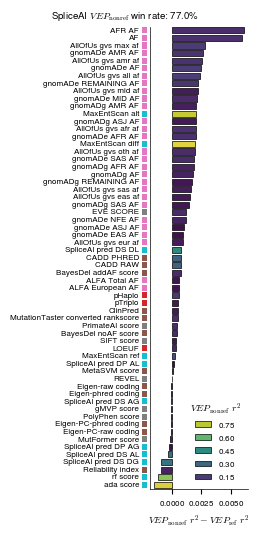

In [521]:
max_p=0.05
# Organize, sort and group keyword arguments by purpose and convention
plot_correlation_analysis_out = ev.plot_correlation_analysis(
    # Data
    r2_df=r2_df.dropna(axis=1, how='all').dropna(axis=0, how='all'),

    # Axes and variables
    x_var="r2_diff",
    max_p=max_p,
    flip_axes=False,
    barplot_kwargs={"edgecolor":"black", "linewidth":0.5},
    # yticklabel_rotation=315,

    draw_positive_negative_divider=False,
    divider_line_kwargs={'color': 'grey', 'linestyle': '--', 'linewidth': 10},

    # Display and category aesthetics
    show_category_legend=False,
    show_category_column=True,
    category_palette="tab10",
    ticklabel_fontsize='small',
    category_legend_bbox_to_anchor=(0.4, 0.3),
    category_box_linewidth=0,
    category_legend_fontsize='small',
    legend_fontsize='small',   
    palette="viridis",

    # Labels and titles
    yticklabel_pad= -.5,
    xlabel=r"$VEP_{\text{nonref}}\ r^2 - VEP_{\text{ref}}\ r^2$",
    legend_title= r"$VEP_{\text{nonref}}\ r^2$",
    title=f"{model_name_display}",
    title_x= -1,
    ylabel=None,
    add_summary_subtitle=True,
    win_rate_on_newline=False,

    # Figure appearance/size
    figsize=(1.4, 6), # Use height 11 for ESM, 8 for Flashzoi and SpliceAI

    # Optional and less-used arguments (commented)
    # min_n=20,
    # max_p=0.05,
    # min_diff=1e-10,
    # annotations=[x for x in ev.ANNOT_COLS if not x.lower().endswith("af") and "SpliceAI" not in x],
)

model_name_tmp="SpliceAI"
plot_correlation_analysis_out['fig'].savefig(
    f"manuscript/fig/vep_correlation_differences_{model_name_tmp}_maxp{max_p}.pdf",
    **utils.FIG_SAVE_KWARGS
)


## Correlate VEP with Population Frequencies

For ESM-series, used this function to compute the superpopulation VEP means.

In [235]:
haplotypes = hs.get_haplotypes(cache_only=True,
                                tx_ids=vep_df['ENST'].unique()
                                ) 
vep_df = hs.add_haplotype_freqs(vep_df, haplotypes=haplotypes)

Found haplotypes of 47329 transcripts in: '/home/schilder/.cache/ensembl_rest/haplotypes'


Getting haplotypes:   0%|          | 0/2141 [00:00<?, ?it/s]

Getting haplotype frequencies:   0%|          | 0/2141 [00:00<?, ?it/s]

Using all 3 cohorts.
Using 38 populations
Adding haplotype frequencies per population
Adding top superpopulation
0 samples are missing superpopulation metadata
0 samples are missing superpopulation metadata

Number of variants specific to each population:
specific_population
1000GENOMES:phase_3:LWK    3113
1000GENOMES:phase_3:JPT    2611
1000GENOMES:phase_3:CHB    2528
1000GENOMES:phase_3:TSI    2447
1000GENOMES:phase_3:CHS    2379
1000GENOMES:phase_3:STU    2328
1000GENOMES:phase_3:ITU    2247
1000GENOMES:phase_3:BEB    2225
1000GENOMES:phase_3:KHV    2195
1000GENOMES:phase_3:MSL    2167
1000GENOMES:phase_3:YRI    2132
1000GENOMES:phase_3:ACB    2032
1000GENOMES:phase_3:IBS    2027
1000GENOMES:phase_3:PJL    2008
1000GENOMES:phase_3:CDX    1974
1000GENOMES:phase_3:PEL    1966
1000GENOMES:phase_3:GIH    1935
1000GENOMES:phase_3:ESN    1837
1000GENOMES:phase_3:CEU    1774
1000GENOMES:phase_3:CLM    1696
1000GENOMES:phase_3:PUR    1683
GGVP:GWD                   1512
1000GENOMES:phase_3:

100%|██████████| 9/9 [00:48<00:00,  5.41s/it]


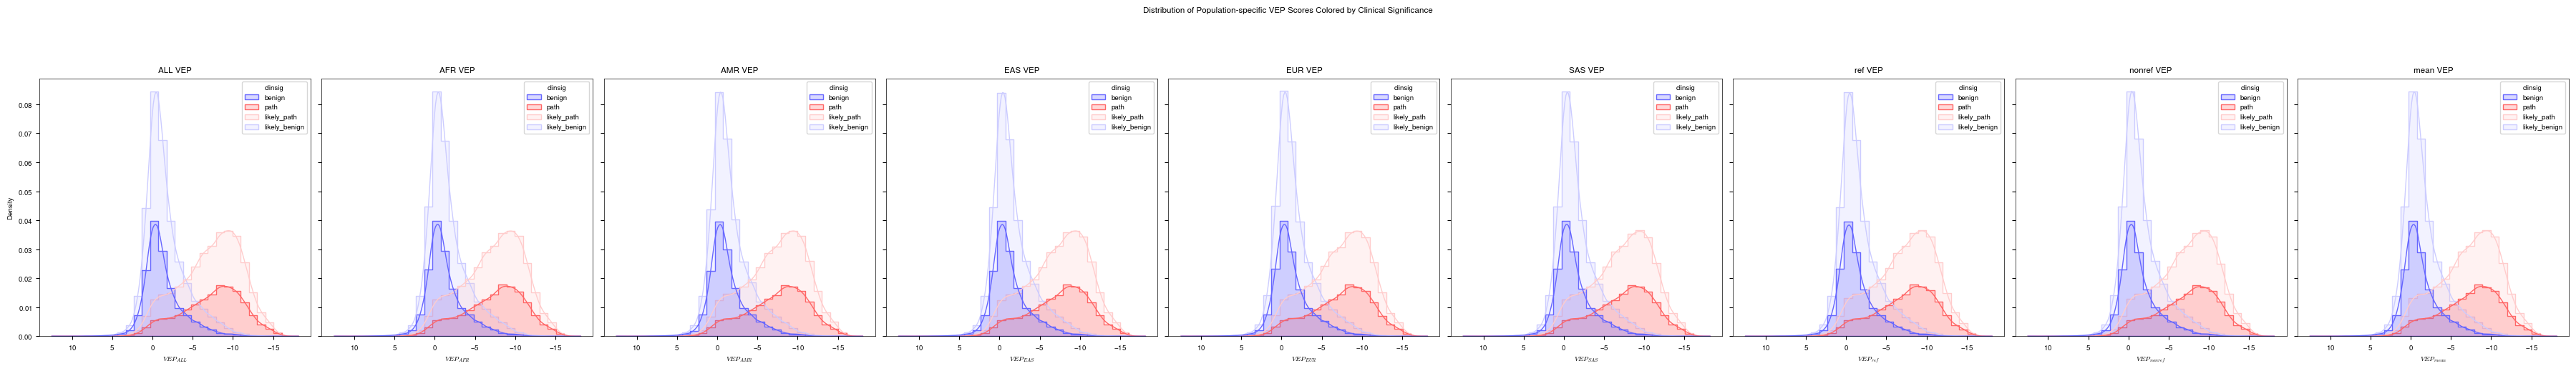

In [ ]:
target_pops = ["ALL", "AFR", "AMR", "EAS", "EUR", "SAS", "ref", "nonref", "mean"]
freq_cols = [x for x in vep_df.columns if x.startswith("freq_1000GENOMES") and any(f":{pop}" in x for pop in target_pops)]

import matplotlib.pyplot as plt
import seaborn as sns

# For each selected population, prepare a subplot of pop-specific VEP distribution colored by clinsig
n_pops = len(target_pops)
fig, axes = plt.subplots(1, n_pops, figsize=(4 * n_pops, 5), sharey=True)
dfs = []

for i, pop in tqdm(enumerate(target_pops), total=len(target_pops)):
    vep_pop_col = f"VEP_{pop}"
    ax = axes[i] if n_pops > 1 else axes
    group_cols = ["site", "clinsig"]
    value_col = "VEP"

    # Prepare data for this population
    if pop == "ref":
        # Just subset to reference haplotypes
        vep_subset = vep_df[vep_df["is_ref"] == True].dropna(subset=["VEP", "clinsig"]).copy()
    elif pop == "nonref" or pop == "vep_nonref":
        # Just subset to non-reference haplotypes (inverted compared to ref)
        vep_subset = vep_df[vep_df["is_ref"] == False].dropna(subset=["VEP", "clinsig"]).copy()
    elif pop == "mean":
        # Use all samples with VEP and clinsig for the unweighted mean
        vep_subset = vep_df.dropna(subset=["VEP", "clinsig"]).copy()
    else:
        freq_col = [x for x in freq_cols if x.endswith(f":{pop}")]
        if not freq_col:
            continue
        freq_col = freq_col[0]
        # Calculate population-weighted VEP
        vep_df[vep_pop_col] = vep_df["VEP"] * vep_df[freq_col]
        vep_df.loc[vep_df[freq_col].isna() | (vep_df[freq_col] == 0), vep_pop_col] = pd.NA
        # Use appropriate subset/columns for grouping/plotting
        vep_subset = vep_df.dropna(subset=[vep_pop_col, freq_col, "clinsig"]).copy()

    # Compute mean VEP per (site, clinsig)
    vep_sp = vep_subset.groupby(group_cols).agg({value_col: "mean"}).reset_index()
    vep_sp.rename(columns={value_col: vep_pop_col}, inplace=True)
    dfs.append(vep_sp)
    sns.histplot(
        data=vep_sp,
        x=vep_pop_col,
        hue="clinsig",
        palette=utils.get_clinsig_palette(),
        kde=True,
        bins=30,
        ax=ax,
        element="step",
        stat="density"
    )

    ax.set_title(f"{pop} VEP")
    ax.set_xlabel(ev.to_latex_subscript(vep_pop_col))
    ax.invert_xaxis()
    if i == 0:
        ax.set_ylabel("Density")
    else:
        ax.set_ylabel("")

plt.tight_layout()
plt.suptitle("Distribution of Population-specific VEP Scores Colored by Clinical Significance", y=1.02)
plt.subplots_adjust(top=0.82)
plt.show()


# Iteratively merge population-specific VEP DataFrames on 'site' and 'clinsig'
from functools import reduce
vep_superpop_agg = reduce(
    lambda left, right: pd.merge(left, right, on=["site", "clinsig"], how="outer"),
    dfs
)
print(vep_superpop_agg.shape)
vep_superpop_agg.head()

For Flashzoi and SpliceAI, used this function to compute the superpopulation VEP means.

In [247]:
vep_superpop_agg = ev.compute_vep_superpopulation_aggregates(vep_df)
print(vep_superpop_agg.shape)
vep_superpop_agg.head()

0 samples are missing superpopulation metadata


Computing superpopulation means:   0%|          | 0/8 [00:00<?, ?it/s]

Computing superpopulation means: 100%|██████████| 8/8 [00:44<00:00,  5.62s/it]


Computing mean VEP per variant across all (non-REF) samples
Computing mean VEP per variant across all (non-REF) samples
Computing mean VEP for reference samples per variant
vep_superpop_agg.shape: (6649, 9)
(6649, 9)


,site,VEP_AFR,VEP_AMR,VEP_EAS,VEP_EUR,VEP_SAS,VEP_mean,VEP_nonref,VEP_ref
0,chr11:10294187-10294188_C_A,0.990552,1.035221,1.055255,1.005049,1.003232,1.015143,1.015143,1.054190
1,chr11:10506578-10506579_A_G,0.109559,0.010608,0.000000,0.003170,0.000000,0.030992,0.030992,0.000000
2,chr11:10506936-10506937_A_G,0.190471,0.029438,0.000000,0.014902,0.001870,0.057663,0.057663,0.000000
3,chr11:10506954-10506955_A_G,0.483014,0.445456,0.496447,0.385231,0.479272,0.459883,0.459883,0.496585
4,chr11:10506974-10506975_A_G,0.018191,0.001047,0.000000,0.001781,0.001498,0.005594,0.005594,0.000000


/home/schilder/.conda/envs/esm2/lib/python3.12/site-packages/seaborn/matrix.py:1124: UserWarning: ``square=True`` ignored in clustermap
  warnings.warn(msg)


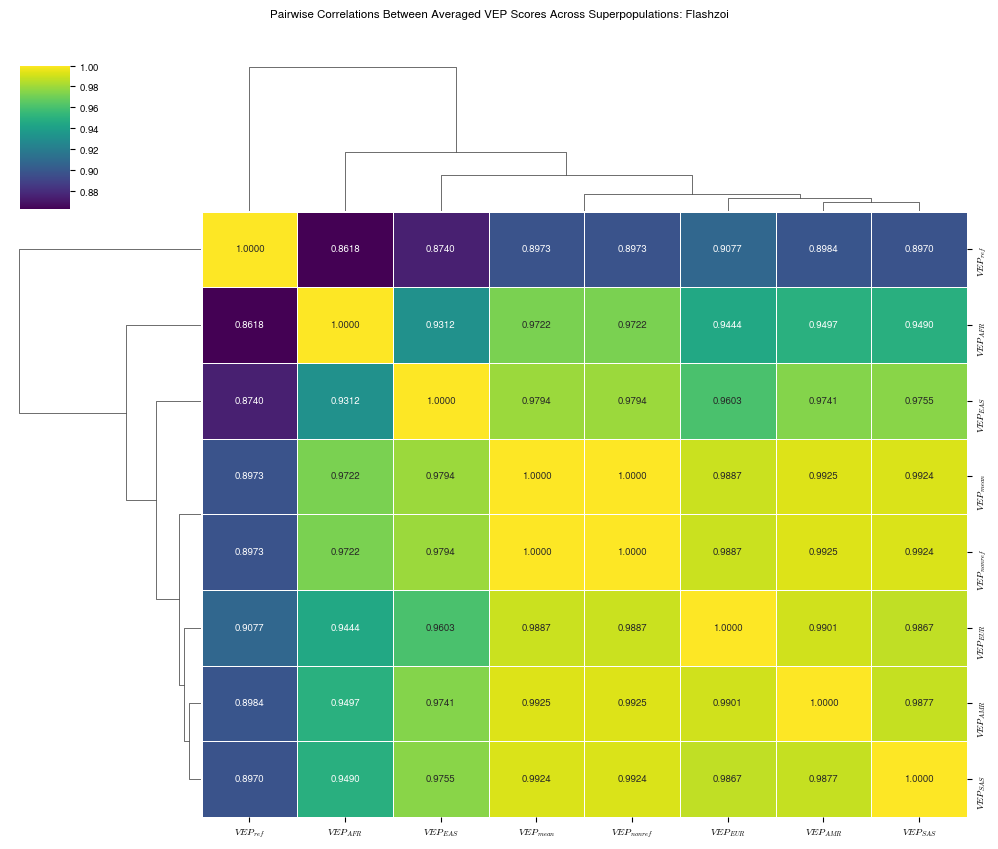

'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


In [248]:
# Select only the columns containing superpopulation VEP means and any other VEP mean columns
vep_cols = [col for col in vep_superpop_agg.columns if col.startswith("VEP_")]

# Compute correlation matrix pairwise, dropping NA pairs for each calculation
vep_corr = vep_superpop_agg[vep_cols].corr(method="spearman", min_periods=1)

# Alternatively, some users may prefer: .corr(method="pearson") with .dropna() per column-pair;
# but recent pandas uses pairwise deletion by default unless interfering groupby/categorical.

# Visualize as clustermap instead of a heatmap
# Remove underscores for display, but keep original data for clustering


vep_corr_display = vep_corr.copy()
vep_corr_display.index = [ev.to_latex_subscript(idx) for idx in vep_corr_display.index]
vep_corr_display.columns = [ev.to_latex_subscript(col) for col in vep_corr_display.columns]

# Show only one triangle of the symmetric correlation matrix

mask = np.triu(np.ones_like(vep_corr, dtype=bool), k=1)  # mask upper triangle
g = sns.clustermap(
    vep_corr,
    annot=True,
    fmt=".4f",
    cmap="viridis",
    linewidths=0.5,
    figsize=(10, 8),
    xticklabels=vep_corr_display.columns,
    yticklabels=vep_corr_display.index,
    # row_cluster=False,
    # mask=mask,
    square=True
)
g.ax_heatmap.set_xticklabels(g.ax_heatmap.get_xticklabels(), rotation=0)

plt.suptitle(f"Pairwise Correlations Between Averaged VEP Scores Across Superpopulations: {model_name}", y=1.05)
plt.show()

g.fig.savefig(f"manuscript/fig/vep_superpop_corr_{model_name}.pdf", **utils.FIG_SAVE_KWARGS)


### Plot AF vs. VEP: matched by superpopulation

In [249]:
# Merge VEP scores with ClinVar annotations
on_cols = ["site"]
rm_cols = [col for col in cv_annot.columns if col not in on_cols and col in vep_superpop_agg.columns]
vep_superpop_annot = vep_superpop_agg.drop(columns=rm_cols).merge(cv_annot.drop_duplicates(subset="site"), on=on_cols, how="inner")
print("vep_superpop_annot.shape:",vep_superpop_annot.shape)
vep_superpop_annot.head() 

vep_superpop_annot.shape: (2977, 498)


,site,VEP_AFR,VEP_AMR,VEP_EAS,VEP_EUR,VEP_SAS,VEP_mean,VEP_nonref,VEP_ref,#Uploaded_variation,Location,Allele,Consequence,IMPACT,SYMBOL,Gene,Feature_type,Feature,BIOTYPE,EXON,INTRON,HGVSc,HGVSp,cDNA_position,CDS_position,Protein_position,Amino_acids,Codons,Existing_variation,REF_ALLELE,UPLOADED_ALLELE,DISTANCE,STRAND,FLAGS,SYMBOL_SOURCE,HGNC_ID,CANONICAL,MANE,MANE_SELECT,MANE_PLUS_CLINICAL,TSL,APPRIS,CCDS,ENSP,SWISSPROT,TREMBL,UNIPARC,UNIPROT_ISOFORM,SOURCE,SIFT,PolyPhen,miRNA,HGVS_OFFSET,AF,AFR_AF,AMR_AF,EAS_AF,EUR_AF,SAS_AF,gnomADe_AF,gnomADe_AFR_AF,gnomADe_AMR_AF,gnomADe_ASJ_AF,gnomADe_EAS_AF,gnomADe_FIN_AF,gnomADe_MID_AF,gnomADe_NFE_AF,gnomADe_REMAINING_AF,gnomADe_SAS_AF,gnomADg_AF,gnomADg_AFR_AF,gnomADg_AMI_AF,gnomADg_AMR_AF,gnomADg_ASJ_AF,gnomADg_EAS_AF,gnomADg_FIN_AF,gnomADg_MID_AF,gnomADg_NFE_AF,gnomADg_REMAINING_AF,gnomADg_SAS_AF,CLIN_SIG,SOMATIC,PHENO,PUBMED,VAR_SYNONYMS,MOTIF_NAME,MOTIF_POS,HIGH_INF_POS,MOTIF_SCORE_CHANGE,TRANSCRIPTION_FACTORS,OpenTargets_geneId,OpenTargets_l2g,CADD_PHRED,CADD_RAW,Mastermind_MMID3,Geno2MP_HPO_count,Geno2MP_URL,ada_score,rf_score,BLOSUM62,Enformer_SAD,Enformer_SAR,NMD,EVE_CLASS,EVE_SCORE,5UTR_annotation,5UTR_consequence,Existing_InFrame_oORFs,Existing_OutOfFrame_oORFs,Existing_uORFs,PHENOTYPES,IntAct_ap_ac,IntAct_feature_ac,IntAct_feature_annotation,IntAct_feature_short_label,IntAct_feature_type,IntAct_interaction_ac,IntAct_interaction_participants,IntAct_pmid,MaveDB_nt,MaveDB_pro,MaveDB_score,MaveDB_urn,pHaplo,pTriplo,SpliceAI_pred_DP_AG,SpliceAI_pred_DP_AL,SpliceAI_pred_DP_DG,SpliceAI_pred_DP_DL,SpliceAI_pred_DS_AG,SpliceAI_pred_DS_AL,SpliceAI_pred_DS_DG,SpliceAI_pred_DS_DL,SpliceAI_pred_SYMBOL,MaxEntScan_alt,MaxEntScan_diff,MaxEntScan_ref,RiboseqORFs_CDS_position,RiboseqORFs_amino_acids,RiboseqORFs_cDNA_position,RiboseqORFs_codons,RiboseqORFs_consequences,RiboseqORFs_id,RiboseqORFs_impact,RiboseqORFs_protein_position,RiboseqORFs_publications,ClinPred,LOEUF,GO,mutfunc_exp,mutfunc_int,mutfunc_mod,mutfunc_motif,1000Gp3_AC,1000Gp3_AF,1000Gp3_AFR_AC,1000Gp3_AFR_AF,1000Gp3_AMR_AC,1000Gp3_AMR_AF,1000Gp3_EAS_AC,1000Gp3_EAS_AF,1000Gp3_EUR_AC,1000Gp3_EUR_AF,1000Gp3_SAS_AC,1000Gp3_SAS_AF,ALFA_African_AC,ALFA_African_AF,ALFA_African_AN,ALFA_African_American_AC,ALFA_African_American_AF,ALFA_African_American_AN,ALFA_African_Others_AC,ALFA_African_Others_AF,ALFA_African_Others_AN,ALFA_Asian_AC,ALFA_Asian_AF,ALFA_Asian_AN,ALFA_East_Asian_AC,ALFA_East_Asian_AF,ALFA_East_Asian_AN,ALFA_European_AC,ALFA_European_AF,ALFA_European_AN,ALFA_Latin_American_1_AC,ALFA_Latin_American_1_AF,ALFA_Latin_American_1_AN,ALFA_Latin_American_2_AC,ALFA_Latin_American_2_AF,ALFA_Latin_American_2_AN,ALFA_Other_AC,ALFA_Other_AF,ALFA_Other_AN,ALFA_Other_Asian_AC,ALFA_Other_Asian_AF,ALFA_Other_Asian_AN,ALFA_South_Asian_AC,ALFA_South_Asian_AF,ALFA_South_Asian_AN,ALFA_Total_AC,ALFA_Total_AF,ALFA_Total_AN,Aloft_Confidence,Aloft_Fraction_transcripts_affected,Aloft_pred,Aloft_prob_Dominant,Aloft_prob_Recessive,Aloft_prob_Tolerant,AlphaMissense_pred,AlphaMissense_rankscore,AlphaMissense_score,AltaiNeandertal,BayesDel_addAF_pred,BayesDel_addAF_rankscore,BayesDel_addAF_score,BayesDel_noAF_pred,BayesDel_noAF_rankscore,BayesDel_noAF_score,ChagyrskayaNeandertal,DANN_rankscore,DANN_score,DEOGEN2_pred,DEOGEN2_rankscore,DEOGEN2_score,Denisova,ESM1b_pred,ESM1b_rankscore,ESM1b_score,Eigen-PC-phred_coding,Eigen-PC-raw_coding,Eigen-PC-raw_coding_rankscore,Eigen-phred_coding,Eigen-raw_coding,Eigen-raw_coding_rankscore,Ensembl_geneid,Ensembl_proteinid,Ensembl_transcriptid,GERP++_NR,GERP++_RS,GERP++_RS_rankscore,GERP_91_mammals,GERP_91_mammals_rankscore,Interpro_domain,LIST-S2_pred,LIST-S2_rankscore,LIST-S2_score,MPC_rankscore,MPC_score,MVP_rankscore,MVP_score,MetaLR_pred,MetaLR_rankscore,MetaLR_score,MetaRNN_pred,MetaRNN_rankscore,MetaRNN_score,MetaSVM_pred,MetaSVM_rankscore,MetaSVM_score,MutFormer_rankscore,MutFormer_score,MutationAssessor_pred,MutationAssessor_rankscore,MutationAssessor_score,MutationTaster_converted_rankscore,MutationTaster

In [250]:
import src.clinvar as cv

vep_superpop_annot = cv.simplify_annotations(vep_superpop_annot)
vep_superpop_annot.loc[vep_superpop_annot["CLNSIG_simple"]=="other", "CLNSIG_simple"] = "VUS"

Using default maps.
Simplifying annotations.


In [362]:
 [col for col in vep_superpop_annot.columns if "AF" in col and not col.startswith("#")]

['VEP_AFR',
 'AF',
 'AFR_AF',
 'AMR_AF',
 'EAS_AF',
 'EUR_AF',
 'SAS_AF',
 'gnomADe_AF',
 'gnomADe_AFR_AF',
 'gnomADe_AMR_AF',
 'gnomADe_ASJ_AF',
 'gnomADe_EAS_AF',
 'gnomADe_FIN_AF',
 'gnomADe_MID_AF',
 'gnomADe_NFE_AF',
 'gnomADe_REMAINING_AF',
 'gnomADe_SAS_AF',
 'gnomADg_AF',
 'gnomADg_AFR_AF',
 'gnomADg_AMI_AF',
 'gnomADg_AMR_AF',
 'gnomADg_ASJ_AF',
 'gnomADg_EAS_AF',
 'gnomADg_FIN_AF',
 'gnomADg_MID_AF',
 'gnomADg_NFE_AF',
 'gnomADg_REMAINING_AF',
 'gnomADg_SAS_AF',
 '1000Gp3_AF',
 '1000Gp3_AFR_AC',
 '1000Gp3_AFR_AF',
 '1000Gp3_AMR_AF',
 '1000Gp3_EAS_AF',
 '1000Gp3_EUR_AF',
 '1000Gp3_SAS_AF',
 'ALFA_African_AF',
 'ALFA_African_American_AF',
 'ALFA_African_Others_AF',
 'ALFA_Asian_AF',
 'ALFA_East_Asian_AF',
 'ALFA_European_AF',
 'ALFA_Latin_American_1_AF',
 'ALFA_Latin_American_2_AF',
 'ALFA_Other_AF',
 'ALFA_Other_Asian_AF',
 'ALFA_South_Asian_AF',
 'ALFA_Total_AF',
 'BayesDel_addAF_pred',
 'BayesDel_addAF_rankscore',
 'BayesDel_addAF_score',
 'BayesDel_noAF_pred',
 'BayesDel_no

In [374]:
# # For Flashzoi, use:
# logy= False,
# logx= True,
# sharex=True,
# epsilon=1e-5,
# hue="CLNSIG_simple",
# minmax_scale_vep=False,
# fit_model="logistic",
# drop_vep_zeros=False,
# invert_xaxis=False,

af_cols = [col for col in vep_superpop_annot.columns if col.endswith("_AF" or col=="AF")]
af_cols_extra=[
     '1000Gp3_AF',
 '1000Gp3_AFR_AF',
 '1000Gp3_AMR_AF',
 '1000Gp3_EAS_AF',
 '1000Gp3_EUR_AF',
 '1000Gp3_SAS_AF',
]
fig, axes, stats_df = ev.plot_vep_vs_af_grid(
    vep_superpop_annot,
    af_cols=['AF', 'gnomADg_AF', 'AFR_AF', 'AMR_AF', 'EAS_AF', 'EUR_AF', 'SAS_AF']+af_cols,
    supertitles=["Population-matched", "Population-unmatched", "Reference"],
    scatter_kwargs={"s": 3},
    alpha=0.5,
    #  logx=True,   # Log-transform VEP
    # logy=True,   # Log-transform AF
    # invert_xaxis=True,
    # minmax_scale_vep=True,
    # fit_model="hyperbolic",
    sharex=True,
    supertitle_y=.03,
    show_xlabels=False,
    hue="CLNSIG_simple",
    #  drop_vep_zeros=True,
    epsilon=1e-2,
    wspace=0,
    hspace=.3,
    height=1.2,
    aspect=1.9,
    rasterize_points=True,
    generate_plot=False,
    # ylim=(0, 1)
)


if fig is not None:
    fig.savefig(
        f"manuscript/fig/vep_vs_af_grid_{model_name}.pdf", 
        **utils.FIG_SAVE_KWARGS
    )

Skipping gnomADe_ASJ_AF: no corresponding VEP_ASJ column found
Skipping gnomADe_FIN_AF: no corresponding VEP_FIN column found
Skipping gnomADe_MID_AF: no corresponding VEP_MID column found
Skipping gnomADe_NFE_AF: no corresponding VEP_NFE column found
Skipping gnomADg_AMI_AF: no corresponding VEP_AMI column found
Skipping gnomADg_ASJ_AF: no corresponding VEP_ASJ column found
Skipping gnomADg_FIN_AF: no corresponding VEP_FIN column found
Skipping gnomADg_MID_AF: no corresponding VEP_MID column found
Skipping gnomADg_NFE_AF: no corresponding VEP_NFE column found
Skipping gnomAD2.1.1_exomes_controls_ASJ_AF: no corresponding VEP_ASJ column found
Skipping gnomAD2.1.1_exomes_controls_FIN_AF: no corresponding VEP_FIN column found
Skipping gnomAD2.1.1_exomes_controls_NFE_AF: no corresponding VEP_NFE column found
Skipping gnomAD2.1.1_exomes_non_cancer_ASJ_AF: no corresponding VEP_ASJ column found
Skipping gnomAD2.1.1_exomes_non_cancer_FIN_AF: no corresponding VEP_FIN column found
Skipping gnomA

In [375]:
stats_df

,af_col,vep_col,n_variants,n_points,fit_model,r2,adj_r2,p_value,rmse,mae,n_fit_points,n_params,params,param_std_err,param_ci_lower,param_ci_upper,logx,logy,minmax_scale_vep,supertitle
0,AF,VEP_nonref,2624,2624,logistic,0.554558,0.554048,1.110223e-16,0.155259,0.106533,2624,3,"[1.0123959753522265, -4.773490335172061, -0.69...","[0.024332042986777172, 0.15952438161696547, 0....","[0.9647051710981432, -5.086158123141313, -0.72...","[1.0600867796063098, -4.460822547202808, -0.66...",True,False,False,Population-matched
1,AF,VEP_mean,2624,2624,logistic,0.554558,0.554048,1.110223e-16,0.155259,0.106533,2624,3,"[1.0123959753522265, -4.773490335172061, -0.69...","[0.024332042986777172, 0.15952438161696547, 0....","[0.9647051710981432, -5.086158123141313, -0.72...","[1.0600867796063098, -4.460822547202808, -0.66...",True,False,False,Population-unmatched
2,AF,VEP_ref,2624,2624,logistic,0.416802,0.416134,1.110223e-16,0.177652,0.127141,2624,3,"[0.7234409366916459, -2.1845840757841968, -0.9...","[0.03281153339484876, 0.19882967519218173, 0.0...","[0.6591303312377423, -2.574290239160873, -1.15...","[0.7877515421455494, -1.7948779124075207, -0.8...",True,False,False,Reference
3,gnomADg_AF,VEP_nonref,2800,2800,logistic,0.557365,0.556890,1.110223e-16,0.152132,0.101235,2800,3,"[1.0012781272305444, -4.984065174126407, -0.69...","[0.022980362386022187, 0.16208523253893642, 0....","[0.9562366169539409, -5.301752229902722, -0.71...","[1.046319637507148, -4.666378118350091, -0.664...",True,False,False,Population-matched
4,gnomADg_AF,VEP_mean,2800,2800,logistic,0.557365,0.556890,1.110223e-16,0.152132,0.101235,2800,3,"[1.0012781272305444, -4.984065174126407, -0.69...","[0.022980362386022187, 0.16208523253893642, 0....","[0.9562366169539409, -5.301752229902722, -0.71...","[1.046319637507148, -4.666378118350091, -0.664...",True,False,False,Population-unmatched
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
178,gnomAD4.1_joint_POPMAX_AF,VEP_mean,397,397,logistic,0.426466,0.422088,1.110223e-16,0.129552,0.056449,397,3,"[1.0512147992511653, -9.171638232491583, -0.62...","[0.07711126455356916, 0.9905469318368023, 0.02...","[0.9000767207261697, -11.113110218891716, -0.6...","[1.202352877776161, -7.230166246091451, -0.568...",True,False,False,Population-unmatched
179,gnomAD4.1_joint_POPMAX_AF,VEP_ref,397,397,logistic,0.379729,0.374995,1.110223e-16,0.134727,0.062598,397,3,"[0.8054957347104688, -4.8748819419731655, -0.7...","[0.051673034907710434, 0.7386707870767723, 0.0...","[0.7042165862913563, -6.322676684643639, -0.91...","[0.9067748831295812, -3.427087199302692, -0.65...",True,False,False,Reference
180,gnomAD4.1_joint_SAS_AF,VEP_SAS,397,397,logistic,0.533542,0.529981,1.110223e-16,0.092126,0.029234,397,3,"[0.9667409843049933, -10.496908840329565, -0.6...","[0.05028391640932067, 1.3632488170226928, 0.02...","[0.8681845081427249, -13.168876521694044, -0.7...","[1.0652974604672618, -7.824941158965087, -0.61...",True,False,False,Population-matched
181,gnomAD4.1_joint_SAS_AF,VEP_mean,397,397,logistic,0.511207,0.507476,1.110223e-16,0.094306,0.031149,397,3,"[0.9822597696577935, -9.2856417011524, -0.6914...","[0.05878403303227096, 0.9673765229801311, 0.02...","[0.8670430649145424, -11.181699686193458, -0.7...","[1.0974764744010446, -7.389583716111344, -0.64...",True,False,False,Population-unmatched


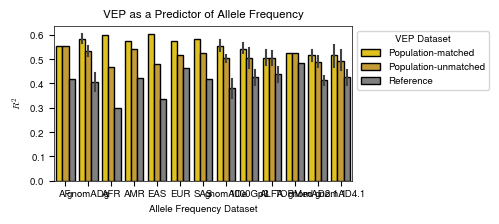

'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


In [376]:
stats_df["af_formatted"] = stats_df["af_col"].apply(ev.to_latex_subscript)
stats_df["af_dataset"] = stats_df["af_col"].str.split("_").str[0]
fig = plt.figure(figsize=(5, 2.25))
ax = sns.barplot(
    data=stats_df, 
    x="af_dataset", 
    y="r2", 
    hue="supertitle",
    edgecolor='black',
    palette=["gold","goldenrod","gray"]
)
ax.set_xlabel("Allele Frequency Dataset")
ax.set_ylabel("$R^2$")
ax.set_title("VEP as a Predictor of Allele Frequency")
# plt.xticks(rotation=45, ha='right')
ax.legend(title="VEP Dataset", bbox_to_anchor=(1, 1), loc="upper left")
plt.tight_layout()
plt.show()


fig.savefig(
    f"manuscript/fig/vep_vs_af_barplot_{model_name}.pdf", 
    **utils.FIG_SAVE_KWARGS
)




In [ ]:
utils.get_superpop_palette()

dict_keys(['AFR', 'AMR', 'EAS', 'EUR', 'SAS', 'CSA', 'MID', 'OCE', 'REF'])

Total number of unique AF labels before processing: 61
Total number of AF labels after processing (for plotting): 61


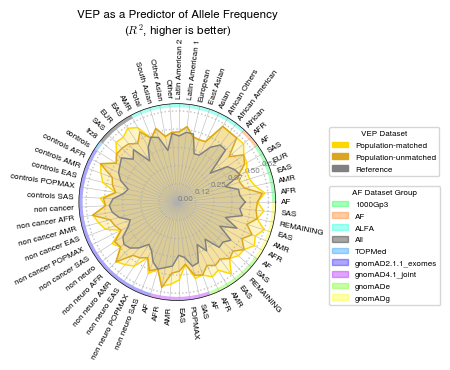

'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


(<Figure size 500x500 with 1 Axes>,
 <PolarAxes: title={'center': 'VEP as a Predictor of Allele Frequency\n($R^2$, higher is better)'}>)

In [532]:

# --- Example usage with current notebook variables ---
ev.plot_vep_vs_af_radar(
    stats_df,
    figsize=5,
    value_col="r2",
    af_col="af_col",
    vep_col="supertitle",
    palette="gist_rainbow",
    family_ring_thickness=0.04, 
    label_ring_padding=-0.1,
    grid_kwargs={'linestyle': ':', 'alpha': 0.75, 'linewidth': 1},
    radial_grid_kwargs={'linestyle': '-', 'alpha': 0.75},
    family_ring_alpha=.35,
    # reverse_area_order=True,


    
    title="VEP as a Predictor of Allele Frequency\n($R^2$, higher is better)",
    title_pad=50,
    linewidth=1,
    legend1_title="VEP Dataset",
    legend2_title="AF Dataset Group",
    legend1_loc=(1.25, .9),
    legend2_loc=(1.25, .6),
    legend_fontsize='small',
    legend_title_fontsize='small',
    tight_layout_kwargs=None,
    group_superpop_as_all=True,
    show=True,
    fig_filename=f"manuscript/fig/vep_vs_af_radarplot_{model_name}.pdf" if "model_name" in globals() else None,
)



In [252]:
import src.vep_analysis as va

# af_cols = [x for x in vep_annot.columns if x.endswith("AF")]
af_cols = [
 'AFR_AF',
 'AMR_AF',
 'EAS_AF',
 'EUR_AF',
 'SAS_AF'
 ]

print(len(af_cols))
vep_annot["VEP_log"] = np.log10(vep_annot["VEP"])
vep_annot["AF_coalesced"] = vep_annot[af_cols].mean(axis=1)

for i, af_col in enumerate(["AF_coalesced"]+af_cols):
    print(af_col)
    va.plot_vep_vs_af(vep_annot.loc[vep_annot["VEP"]!=0],
                    vep_col="VEP",
                    af_col=af_col,  # Use the current af_col instead of hardcoding AF_TGP
                    # fit_line=False,
                    # show_ci=False,
                    logx=True,
                    logy=False,
                    sharex=False,
                    # sharey=False,
                    col="is_ref", 
                    hue="CLNSIG_simple", 
                    height=4,
                    aspect=1.25,
                    ylim=(0, 1))  # Plot on the corresponding subplot axis 

    if i >5:
        break

5
AF_coalesced


/home/schilder/.conda/envs/esm2/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


AttributeError: module 'src.vep_analysis' has no attribute 'plot_vep_vs_af'